# Data Loading and Augmentation Using PyTorch

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 1

**Objective:** Build a custom transformation pipeline and PyTorch
`Dataset`/`DataLoader` for the agricultural / non-agricultural satellite
tile dataset.


## 1. Import libraries and packages

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)

DATA_DIR = "images_dataSAT"
assert os.path.isdir(DATA_DIR), f"'{DATA_DIR}' not found in the working directory."


PyTorch: 2.12.1+cu130


### Task 1: Define `custom_transform`

* Image size = 64 x 64 pixels
* `RandomHorizontalFlip` probability 0.5
* `RandomVerticalFlip` probability 0.2
* `RandomRotation` of 45 degrees


In [2]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
])

print(custom_transform)


Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
)


### Task 2: Load dataset using `datasets.ImageFolder` with `custom_transform`

In [3]:
imagefolder_dataset = datasets.ImageFolder(root=DATA_DIR, transform=custom_transform)

print(f"Total samples: {len(imagefolder_dataset)}")


Total samples: 6000


### Task 3: Print class names and indices from `imagefolder_dataset`

In [4]:
print("Class names:", imagefolder_dataset.classes)
print("Class -> index mapping:", imagefolder_dataset.class_to_idx)


Class names: ['class_0_non_agri', 'class_1_agri']
Class -> index mapping: {'class_0_non_agri': 0, 'class_1_agri': 1}


### Task 4: Retrieve and display image shapes from a batch in `imagefolder_loader`

In [5]:
imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=8, shuffle=True)

batch_images, batch_labels = next(iter(imagefolder_loader))
print(f"Batch images shape: {batch_images.shape}")  # (batch, C, H, W)
print(f"Batch labels shape: {batch_labels.shape}")
print(f"Individual image shape: {batch_images[0].shape}")


Batch images shape: torch.Size([8, 3, 64, 64])
Batch labels shape: torch.Size([8])
Individual image shape: torch.Size([3, 64, 64])


### Task 5: Display images in the custom loader batch

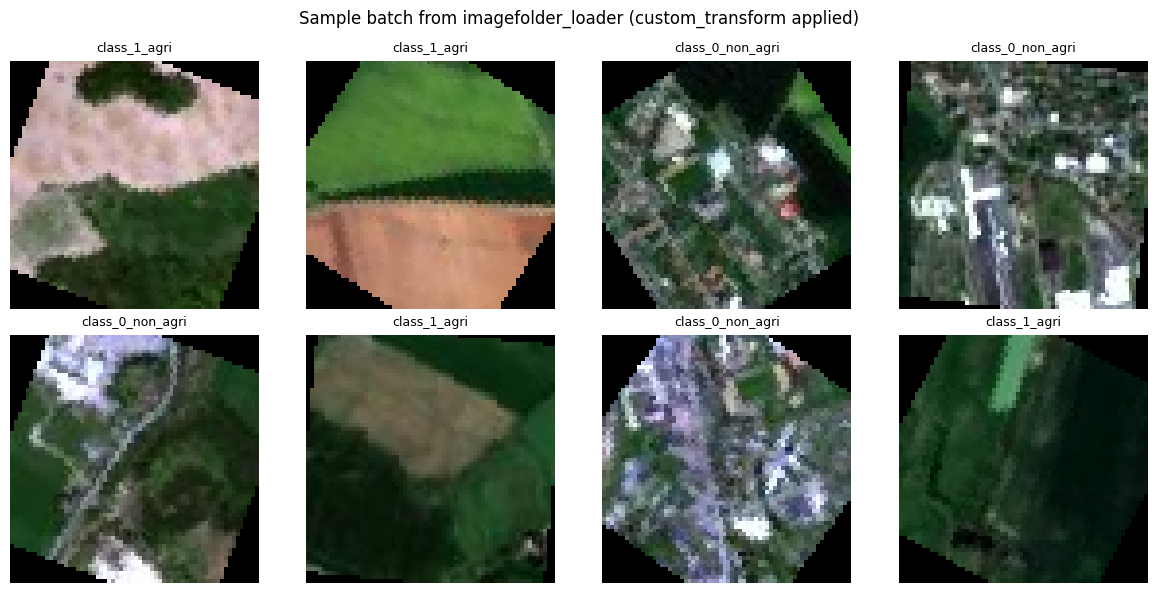

In [6]:
idx_to_class = {v: k for k, v in imagefolder_dataset.class_to_idx.items()}

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flat, batch_images, batch_labels):
    img_disp = img.permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
    ax.imshow(np.clip(img_disp, 0, 1))
    ax.set_title(idx_to_class[label.item()], fontsize=9)
    ax.axis("off")

plt.suptitle("Sample batch from imagefolder_loader (custom_transform applied)")
plt.tight_layout()
plt.show()


## Summary

We defined `custom_transform` (resize to 64x64, random horizontal flip
p=0.5, random vertical flip p=0.2, random rotation of 45 degrees),
loaded the dataset with `datasets.ImageFolder` into
`imagefolder_dataset`, inspected its class mapping, and used
`imagefolder_loader` (a `DataLoader` wrapping the dataset) to retrieve
and visualize an augmented batch.
